In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('C:\\Users\\prath\\MultilModel\\data\\german_credit_data.csv')
data.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [5]:
# translate German-to-English
# !pip install deep-translator

In [6]:
from deep_translator import GoogleTranslator
translator = GoogleTranslator(source='de',target='en')

new_cols = {translator.translate(col) for col in data.columns}
print(new_cols)


{'age', 'best time', 'telephone', 'famges', 'rate', 'height', 'wide credit', 'moral', 'savings account', 'personal', 'presumably', 'credit', 'residential', 'current account', 'use', 'living time', 'profession', 'guarantor', 'gastrob', 'duration', 'bishkred'}


In [3]:
data.columns

Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='object')

In [4]:
column_mapping = {
    "laufkont": "checking_account_status",
    "laufzeit": "duration_months",
    "moral": "credit_history",
    "verw": "purpose",
    "hoehe": "credit_amount",
    "sparkont": "savings_account",
    "beszeit": "employment_since",
    "rate": "installment_rate",
    "famges": "personal_status_sex",
    "buerge": "other_debtors",
    "wohnzeit": "residence_since",
    "verm": "property",
    "alter": "age",
    "weitkred": "other_installment_plans",
    "wohn": "housing",
    "bishkred": "existing_credits",
    "beruf": "job",
    "pers": "people_liable",
    "telef": "telephone",
    "gastarb": "foreign_worker",
    "kredit": "credit_risk"
}

data.rename(columns=column_mapping, inplace=True)

print(data.columns)

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account', 'employment_since',
       'installment_rate', 'personal_status_sex', 'other_debtors',
       'residence_since', 'property', 'age', 'other_installment_plans',
       'housing', 'existing_credits', 'job', 'people_liable', 'telephone',
       'foreign_worker', 'credit_risk'],
      dtype='object')


In [5]:
data.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [6]:
data['credit_risk'].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

In [7]:
data.corr()['credit_risk'].sort_values(ascending=False)

credit_risk                1.000000
checking_account_status    0.350847
credit_history             0.228785
savings_account            0.178943
employment_since           0.116002
other_installment_plans    0.109844
age                        0.091272
personal_status_sex        0.088184
existing_credits           0.045732
telephone                  0.036466
other_debtors              0.025137
housing                    0.018119
residence_since           -0.002967
people_liable             -0.003015
purpose                   -0.017979
job                       -0.032735
installment_rate          -0.072404
foreign_worker            -0.082079
property                  -0.142612
credit_amount             -0.154740
duration_months           -0.214927
Name: credit_risk, dtype: float64

In [8]:
data.checking_account_status.value_counts()

checking_account_status
4    394
1    274
2    269
3     63
Name: count, dtype: int64

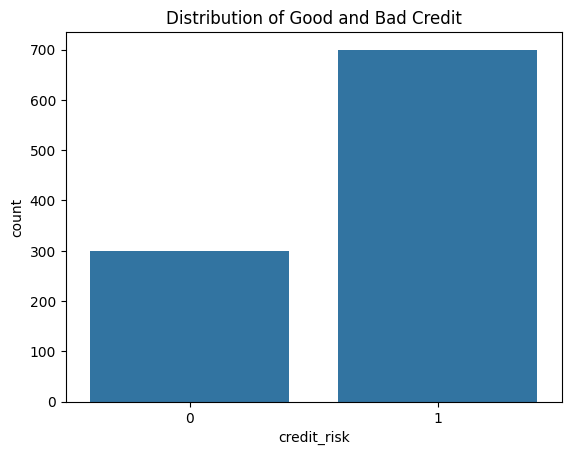

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=data, x=data['credit_risk'])
plt.title("Distribution of Good and Bad Credit")
plt.show()

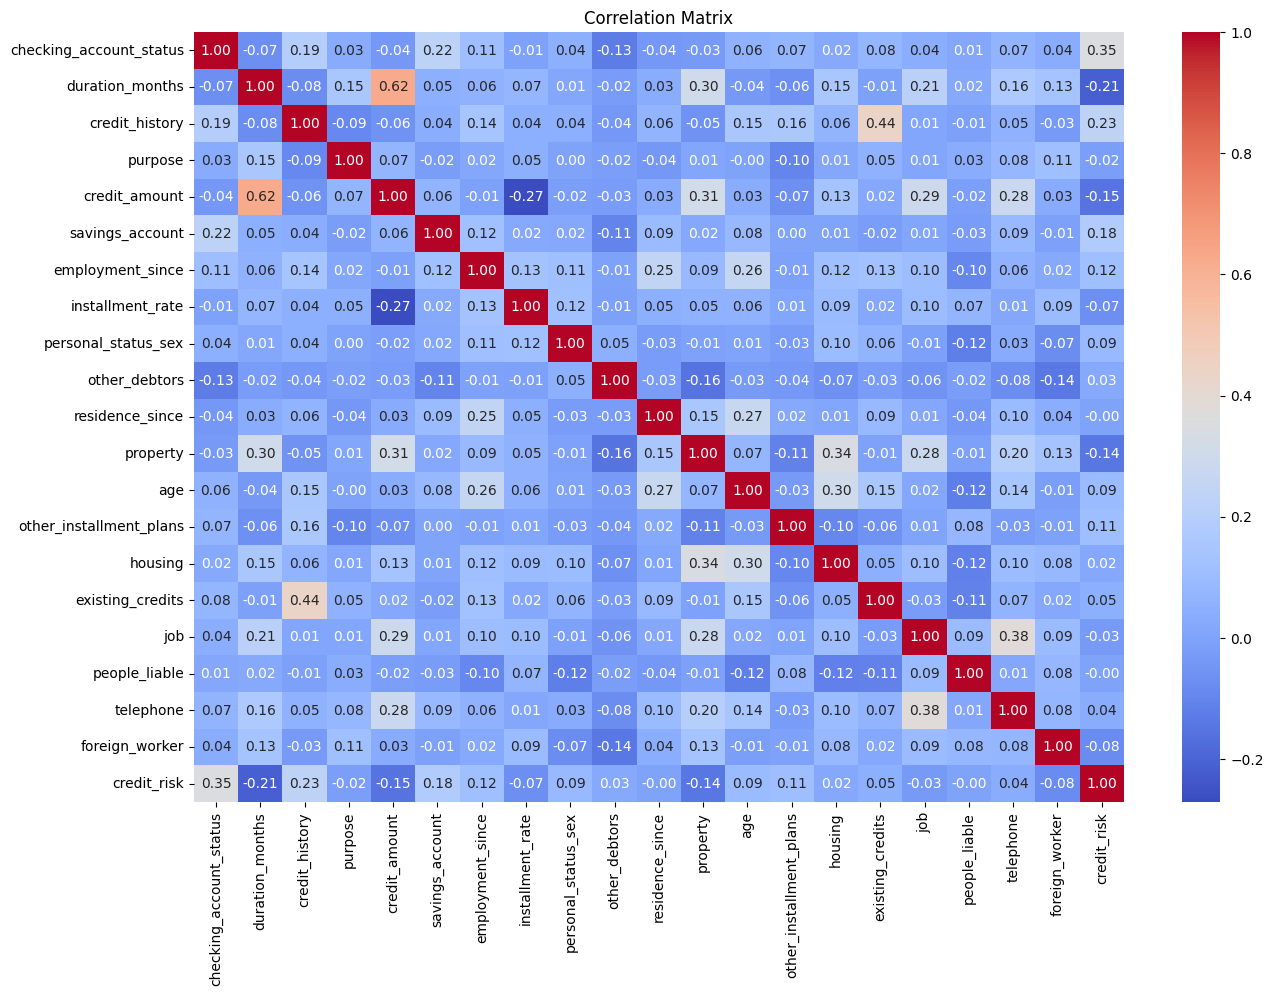

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

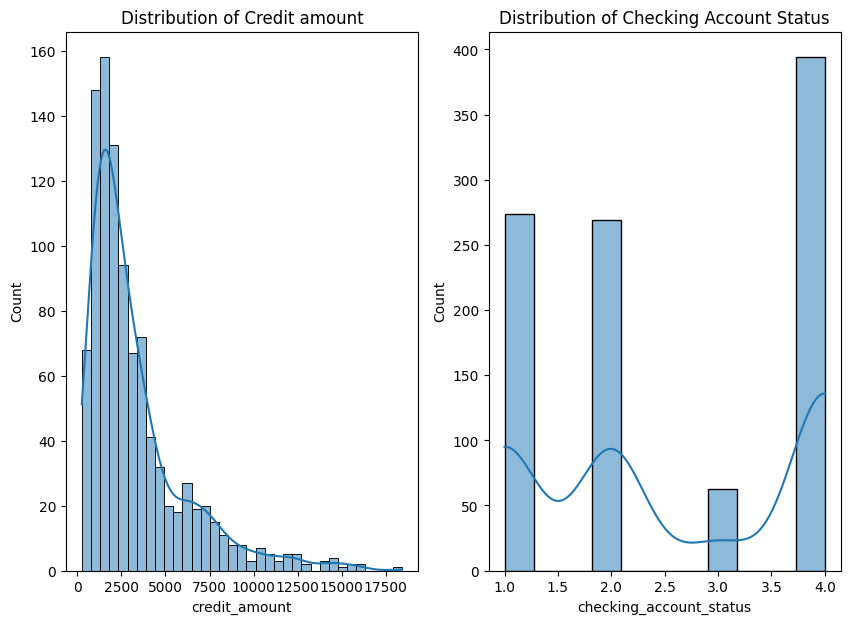

In [27]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
sns.histplot(data['credit_amount'],kde=True)
plt.title("Distribution of Credit amount")
plt.subplot(1,2,2)
sns.histplot(data['checking_account_status'],kde=True)
plt.title("Distribution of Checking Account Status")
plt.show()

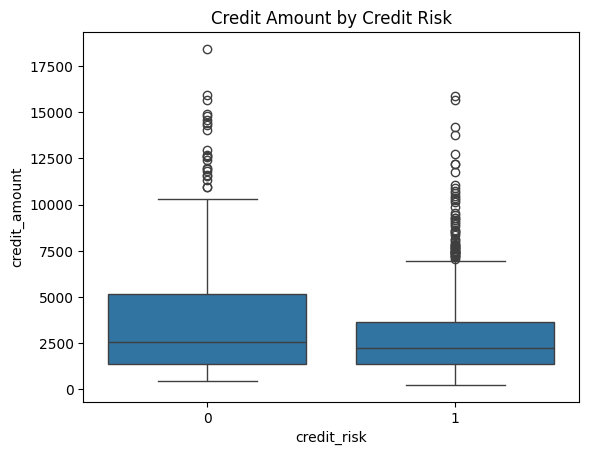

In [17]:
sns.boxplot(data=data, x=data['credit_risk'], y=data['credit_amount'])
plt.title("Credit Amount by Credit Risk")
plt.show()